### Imports

In [1]:
import torch
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import os
from torchvision.transforms import transforms

import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.metrics import accuracy_score, classification_report

### Load ResNet18 Model + GRU (with temporal differencing)

In [2]:
class Experiment3(nn.Module):
    def __init__(self, num_classes=4):
        super(Experiment3, self).__init__()
        # load pretrained model
        resnet_model = resnet18(weights=ResNet18_Weights.DEFAULT)

        # remove last fully connected layer
        self.feature_extractor = nn.Sequential(*list(resnet_model.children())[:-1])

        # define GRU
        self.gru = nn.GRU(input_size=512, hidden_size=128, batch_first=True) # hidden_size möglicherweise anpassen

        # final classifier
        self.fc = nn.Linear(128, num_classes) 


    def forward(self,x):
        batch_size, seq_len, channels, height, width = x.size()

        # use ResNet for each picture in the sequence
        x = x.view(batch_size * seq_len, channels, height, width)
        with torch.no_grad(): # ResNet eingefroren
            features = self.feature_extractor(x)

        # bring features into right sequential form
        features = torch.flatten(features, 1)
        features = features.view(batch_size, seq_len, -1)
        features = features[:, 1:, :] - features[:, :-1, :] # hinzugefügt

        gru_out, hn = self.gru(features)

        last_hidden_state = hn[-1]

        output = self.fc(last_hidden_state)
        return output

### Load Dataset

In [3]:
# define path 
DATASET_PATH = "/Users/gwen/Desktop/video_frames_data"
CSV_PATH = os.path.join(DATASET_PATH, "metadata.csv")

# load dataset
class VideoDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.df = dataframe 
        self.root_dir = root_dir
        self.transform = transform
        self.seq_len = 8 

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        video_folder = os.path.join(self.root_dir, row['frame_dir'] )

        video_class = int(row['class_id']) 

        img_sequence = sorted(os.listdir(video_folder))


        frames = []
        for img_name in img_sequence:
            img_path = os.path.join(video_folder, img_name)
            image = Image.open(img_path).convert('RGB') # to make 100% sure
            if self.transform:
                image = self.transform(image)
            frames.append(image)

        return torch.stack(frames), video_class


# define transformations for our dataset
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

# load full csv
full_df = pd.read_csv(CSV_PATH)

full_df['frame_dir'] = full_df['frame_dir'].str.replace('\\', '/', regex=False) # wegen Windows und Mac

# load training data
train_df = full_df[full_df['split'] == 'train'].reset_index(drop=True)
# load validation data
val_df = full_df[full_df['split'] == 'val'].reset_index(drop=True)

# Dataset and Loader
train_dataset = VideoDataset(dataframe=train_df, root_dir=DATASET_PATH, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataset = VideoDataset(dataframe=val_df, root_dir=DATASET_PATH, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)


### Training Loop

In [4]:
# training loop 
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    # determine device
    device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

    for epoch in range(num_epochs):
        # training mode
        model.train()

        running_loss = 0.0
        running_corrects = 0

        # iterate training data loader
        for inputs, labels in train_loader:
            # put to device
            inputs = inputs.to(device)
            labels = labels.to(device)

            # reset gradients 
            optimizer.zero_grad()

            # forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            # backward pass
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        # epoch training loss and accuracy 
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = running_corrects.float() / len(train_loader.dataset)


        ## Evaluation
        model.eval()
        running_loss = 0.0
        running_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # forward pass
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

        # validation loss and accuracy 
        val_loss = running_loss / len(val_loader.dataset)
        val_acc = running_corrects.float() / len(val_loader.dataset)

        print(f'Epoch [{epoch+1}/{num_epochs}], train loss: {train_loss:.4f}, train acc: {train_acc:.4f}, val loss: {val_loss:.4f}, val acc: {val_acc:.4f} \n')

In [5]:
# train model
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model = Experiment3(num_classes=4).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001) 

train(model, train_loader, val_loader, criterion, optimizer, num_epochs=20)

# save checkpoint of model
checkpoint = {
    "model7_state_dict": model.state_dict(),
    "optimizer_model7_state_dict": optimizer.state_dict(),
    "epoch": 20,
}

torch.save(
    checkpoint,
    "checkpoints/model7_checkpoint.pth"
)

Epoch [1/20], train loss: 1.2402, train acc: 0.4457, val loss: 0.9916, val acc: 0.5842 

Epoch [2/20], train loss: 0.8067, train acc: 0.6704, val loss: 0.8267, val acc: 0.6667 

Epoch [3/20], train loss: 0.5603, train acc: 0.7907, val loss: 0.8059, val acc: 0.6561 

Epoch [4/20], train loss: 0.3692, train acc: 0.8752, val loss: 0.8606, val acc: 0.6491 

Epoch [5/20], train loss: 0.2249, train acc: 0.9207, val loss: 0.9871, val acc: 0.6561 

Epoch [6/20], train loss: 0.1341, train acc: 0.9583, val loss: 1.0508, val acc: 0.6561 

Epoch [7/20], train loss: 0.0741, train acc: 0.9808, val loss: 1.1726, val acc: 0.6596 

Epoch [8/20], train loss: 0.0390, train acc: 0.9906, val loss: 1.1903, val acc: 0.6561 

Epoch [9/20], train loss: 0.0287, train acc: 0.9917, val loss: 1.3253, val acc: 0.6561 

Epoch [10/20], train loss: 0.0518, train acc: 0.9835, val loss: 1.2023, val acc: 0.6754 

Epoch [11/20], train loss: 0.0296, train acc: 0.9929, val loss: 1.3359, val acc: 0.6614 

Epoch [12/20], trai

### Evaluation 

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


def evaluate_GRU_model(model, loader, device):
    model.eval()

    true_labels = []
    preds = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            true_labels.extend(labels.cpu().numpy())
            preds.extend(predicted.cpu().numpy())


    print(f"Overall Accuracy: {accuracy_score(true_labels, preds):.4f}")
    print(classification_report(true_labels, preds))

    cm = confusion_matrix(
        true_labels,
        preds,
        labels=[0, 1, 2, 3]
    )

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["class1", "class2", "class3", "class4"],
        yticklabels=["class1", "class2", "class3", "class4"]
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.title("GRU Model - Confusion Matrix")
    plt.tight_layout()
    plt.show()

    
    report = classification_report(true_labels, preds, output_dict=True)
    return accuracy_score(true_labels, preds), {f"class{i+1}": report[str(i)]["recall"] for i in range(4) if str(i) in report}

Overall Accuracy: 0.6456
              precision    recall  f1-score   support

           0       0.86      0.81      0.84       144
           1       0.57      0.49      0.53       142
           2       0.62      0.61      0.61       142
           3       0.55      0.67      0.61       142

    accuracy                           0.65       570
   macro avg       0.65      0.65      0.65       570
weighted avg       0.65      0.65      0.65       570



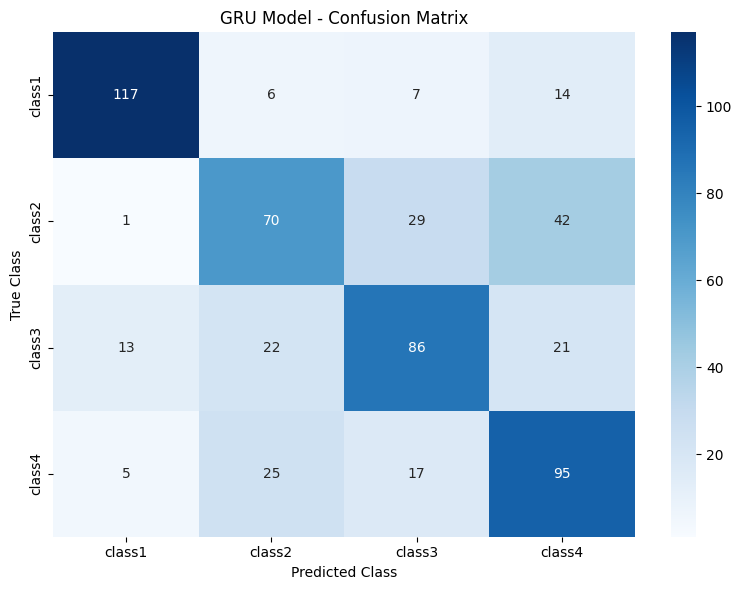

In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

#load model
gru_model = Experiment3(num_classes=4).to(device)
checkpoint = torch.load("checkpoints/model7_checkpoint.pth", map_location=device)
gru_model.load_state_dict(checkpoint["model7_state_dict"])

acc_GRU_model, acc_classes_GRU_model = evaluate_GRU_model(gru_model, val_loader, device)

### Load ResNet18 Model + GRU (with temporal differencing and weight decay, dropout and bidirectional)

In [2]:
class Experiment3(nn.Module):
    def __init__(self, num_classes=4):
        super(Experiment3, self).__init__()
        # load pretrained model
        resnet_model = resnet18(weights=ResNet18_Weights.DEFAULT)

        # remove last fully connected layer
        self.feature_extractor = nn.Sequential(*list(resnet_model.children())[:-1])

        # define GRU
        self.gru = nn.GRU(input_size=512, hidden_size=128, batch_first=True, bidirectional=True) # hidden_size möglicherweise anpassen

        self.dropout = nn.Dropout(0.5) # Dropout hinzugefügt

        # final classifier
        self.fc = nn.Linear(128 * 2 , num_classes) #wegen bidirectional


    def forward(self,x):
        batch_size, seq_len, channels, height, width = x.size()

        # use ResNet for each picture in the sequence
        x = x.view(batch_size * seq_len, channels, height, width)
        with torch.no_grad(): # ResNet eingefroren
            features = self.feature_extractor(x)

        # bring features into right sequential form
        features = torch.flatten(features, 1)
        features = features.view(batch_size, seq_len, -1)
        features = features[:, 1:, :] - features[:, :-1, :] # hinzugefügt

        gru_out, hn = self.gru(features)

        pooled_state = torch.mean(gru_out, dim=1)

        last_hidden_state = self.dropout(pooled_state)

        output = self.fc(last_hidden_state)
        return output

### Load Dataset

In [3]:
# define path 
DATASET_PATH = "/Users/gwen/Desktop/video_frames_data"
CSV_PATH = os.path.join(DATASET_PATH, "metadata.csv")

# load dataset
class VideoDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.df = dataframe 
        self.root_dir = root_dir
        self.transform = transform
        self.seq_len = 8 

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        video_folder = os.path.join(self.root_dir, row['frame_dir'] )

        video_class = int(row['class_id']) 

        img_sequence = sorted(os.listdir(video_folder))


        frames = []
        for img_name in img_sequence:
            img_path = os.path.join(video_folder, img_name)
            image = Image.open(img_path).convert('RGB') # to make 100% sure
            if self.transform:
                image = self.transform(image)
            frames.append(image)

        return torch.stack(frames), video_class


# define transformations for our dataset
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

# load full csv
full_df = pd.read_csv(CSV_PATH)

full_df['frame_dir'] = full_df['frame_dir'].str.replace('\\', '/', regex=False) # wegen Windows und Mac

# load training data
train_df = full_df[full_df['split'] == 'train'].reset_index(drop=True)
# load validation data
val_df = full_df[full_df['split'] == 'val'].reset_index(drop=True)

# Dataset and Loader
train_dataset = VideoDataset(dataframe=train_df, root_dir=DATASET_PATH, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataset = VideoDataset(dataframe=val_df, root_dir=DATASET_PATH, transform=transform)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)


### Training Loop

In [4]:
# training loop 
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    # determine device
    device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

    for epoch in range(num_epochs):
        # training mode
        model.train()

        running_loss = 0.0
        running_corrects = 0

        # iterate training data loader
        for inputs, labels in train_loader:
            # put to device
            inputs = inputs.to(device)
            labels = labels.to(device)

            # reset gradients 
            optimizer.zero_grad()

            # forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            # backward pass
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        # epoch training loss and accuracy 
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = running_corrects.float() / len(train_loader.dataset)


        ## Evaluation
        model.eval()
        running_loss = 0.0
        running_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # forward pass
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

        # validation loss and accuracy 
        val_loss = running_loss / len(val_loader.dataset)
        val_acc = running_corrects.float() / len(val_loader.dataset)

        print(f'Epoch [{epoch+1}/{num_epochs}], train loss: {train_loss:.4f}, train acc: {train_acc:.4f}, val loss: {val_loss:.4f}, val acc: {val_acc:.4f} \n')

In [5]:
# train model
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model = Experiment3(num_classes=4).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001, weight_decay=1e-4) 

train(model, train_loader, val_loader, criterion, optimizer, num_epochs=10)

# save checkpoint of model
checkpoint = {
    "model11_state_dict": model.state_dict(),
    "optimizer_model11_state_dict": optimizer.state_dict(),
    "epoch": 10,
}

torch.save(
    checkpoint,
    "checkpoints/model11_checkpoint.pth"
)

Epoch [1/10], train loss: 1.2521, train acc: 0.4480, val loss: 0.9789, val acc: 0.5982 

Epoch [2/10], train loss: 0.8378, train acc: 0.6531, val loss: 0.8201, val acc: 0.6526 

Epoch [3/10], train loss: 0.6052, train acc: 0.7636, val loss: 0.7935, val acc: 0.6825 

Epoch [4/10], train loss: 0.4420, train acc: 0.8301, val loss: 0.8400, val acc: 0.6684 

Epoch [5/10], train loss: 0.2970, train acc: 0.8989, val loss: 0.8777, val acc: 0.6667 

Epoch [6/10], train loss: 0.1849, train acc: 0.9376, val loss: 1.0141, val acc: 0.6316 

Epoch [7/10], train loss: 0.1386, train acc: 0.9557, val loss: 1.1181, val acc: 0.6333 

Epoch [8/10], train loss: 0.0701, train acc: 0.9835, val loss: 1.1543, val acc: 0.6439 

Epoch [9/10], train loss: 0.0488, train acc: 0.9876, val loss: 1.2830, val acc: 0.6386 

Epoch [10/10], train loss: 0.0807, train acc: 0.9756, val loss: 1.1552, val acc: 0.6614 



In [6]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


def evaluate_GRU_model(model, loader, device):
    model.eval()

    true_labels = []
    preds = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            true_labels.extend(labels.cpu().numpy())
            preds.extend(predicted.cpu().numpy())


    print(f"Overall Accuracy: {accuracy_score(true_labels, preds):.4f}")
    print(classification_report(true_labels, preds))

    cm = confusion_matrix(
        true_labels,
        preds,
        labels=[0, 1, 2, 3]
    )

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["class1", "class2", "class3", "class4"],
        yticklabels=["class1", "class2", "class3", "class4"]
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.title("GRU Model - Confusion Matrix")
    plt.tight_layout()
    plt.show()

    
    report = classification_report(true_labels, preds, output_dict=True)
    return accuracy_score(true_labels, preds), {f"class{i+1}": report[str(i)]["recall"] for i in range(4) if str(i) in report}

Overall Accuracy: 0.6614
              precision    recall  f1-score   support

           0       0.84      0.78      0.81       144
           1       0.59      0.58      0.59       142
           2       0.61      0.67      0.64       142
           3       0.61      0.61      0.61       142

    accuracy                           0.66       570
   macro avg       0.66      0.66      0.66       570
weighted avg       0.67      0.66      0.66       570



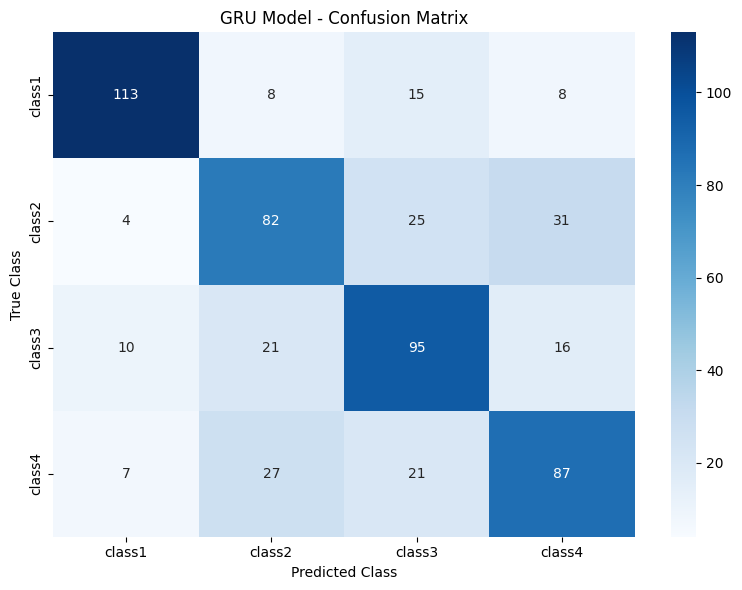

In [7]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

#load model
gru_model = Experiment3(num_classes=4).to(device)
checkpoint = torch.load("checkpoints/model11_checkpoint.pth", map_location=device)
gru_model.load_state_dict(checkpoint["model11_state_dict"])

acc_GRU_model, acc_classes_GRU_model = evaluate_GRU_model(gru_model, val_loader, device)


Model 7 - temporal differences
Model 8 - drop out und weight decay
Model 9 - smaller hidden size bei GRU
Model 10 - global average pooling
Model 11 - + bidirectional 
